<a href="https://colab.research.google.com/github/ciril7/Applied-Computer-Vision-NLP-IIITK/blob/main/Day%202/hog_contour_convolution_hands_on_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hands-on: HOG, Contours and Convolution on One Image

Upload one image and observe how classical computer vision and convolution look at the same image in different ways.

**Flow:**  
Image → Grayscale → Gradients → HOG → Contours → Convolution


In [1]:
# Basic libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from skimage.feature import hog
from skimage import exposure

plt.rcParams["figure.figsize"] = (10, 5)

## 1. Upload one image

Use any clear image: object, person, vehicle, coin, mug, leaf, etc.  
A simple image with a clear boundary works best.


Saving cat.jpg to cat.jpg


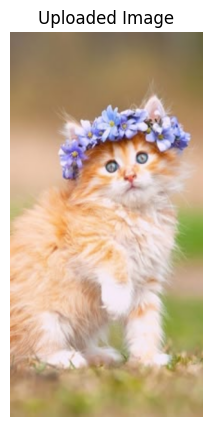

In [2]:
uploaded = files.upload()

image_name = list(uploaded.keys())[0]
image_bgr = cv2.imread(image_name)

# OpenCV reads images in BGR format. Convert it to RGB for display.
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Resize only for comfortable display and processing.
image_rgb = cv2.resize(image_rgb, (300, 600))

plt.imshow(image_rgb)
plt.title("Uploaded Image")
plt.axis("off")
plt.show()

## 2. Convert image to grayscale

Most traditional computer vision methods start with grayscale because they focus on intensity changes.


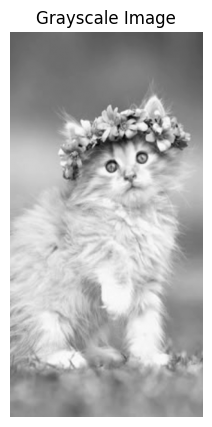

Image size: (600, 300)


In [3]:
gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

print("Image size:", gray.shape)

## 3. Gradient: where brightness changes

A gradient tells where the image intensity changes strongly.  
Strong changes usually appear near edges.


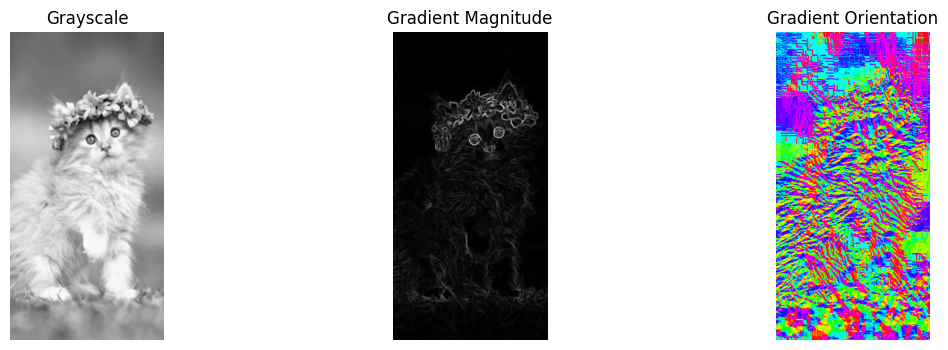

In [4]:
# Sobel gradients in x and y directions
grad_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
grad_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

magnitude = np.sqrt(grad_x**2 + grad_y**2)
orientation = np.arctan2(grad_y, grad_x)

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(magnitude, cmap="gray")
plt.title("Gradient Magnitude")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(orientation, cmap="hsv")
plt.title("Gradient Orientation")
plt.axis("off")

plt.show()

## 4. HOG: summarising edge directions

HOG does not store every pixel directly.  
It summarises edge directions in small regions of the image.


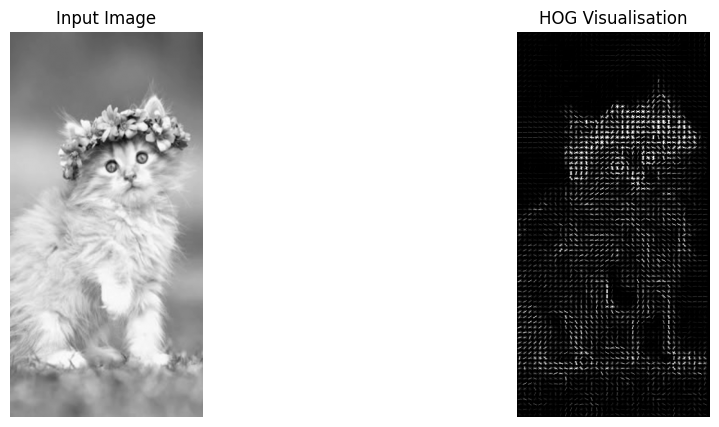

HOG feature vector length: 95904


In [5]:
hog_features, hog_image = hog(
    gray,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
    visualize=True,
    feature_vector=True
)

# Improve visibility of the HOG image
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hog_image_rescaled, cmap="gray")
plt.title("HOG Visualisation")
plt.axis("off")

plt.show()

print("HOG feature vector length:", len(hog_features))

## 5. Contours: tracing object boundaries

Contours are useful when the shape or boundary of an object is important.


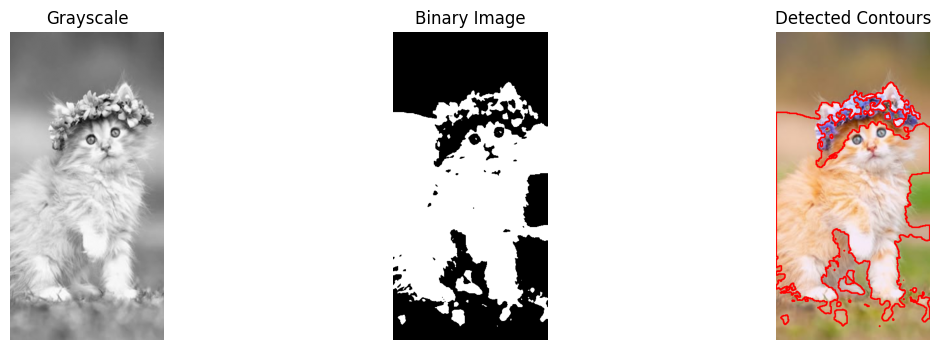

Number of contours detected: 28


In [6]:
# Smooth the image slightly before thresholding
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# Otsu threshold automatically chooses a threshold value
_, binary = cv2.threshold(
    blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# If the object becomes black and background becomes white, invert it
white_pixels = np.sum(binary == 255)
black_pixels = np.sum(binary == 0)

if white_pixels > black_pixels:
    binary = cv2.bitwise_not(binary)

contours, hierarchy = cv2.findContours(
    binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)

contour_image = image_rgb.copy()
cv2.drawContours(contour_image, contours, -1, (255, 0, 0), 2)

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(contour_image)
plt.title("Detected Contours")
plt.axis("off")

plt.show()

print("Number of contours detected:", len(contours))

## 6. Basic contour measurements

Area and perimeter are simple shape features.


In [7]:
# Keep only reasonably large contours
valid_contours = []

for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > 200:
        valid_contours.append(cnt)

print("Large contours found:", len(valid_contours))

for i, cnt in enumerate(valid_contours[:5]):
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)
    x, y, w, h = cv2.boundingRect(cnt)

    print(f"Contour {i+1}")
    print("  Area:", round(area, 2))
    print("  Perimeter:", round(perimeter, 2))
    print("  Bounding box:", (x, y, w, h))

Large contours found: 4
Contour 1
  Area: 576.5
  Perimeter: 99.84
  Bounding box: (113, 540, 26, 33)
Contour 2
  Area: 622.0
  Perimeter: 177.2
  Bounding box: (273, 506, 27, 59)
Contour 3
  Area: 1087.5
  Perimeter: 222.41
  Bounding box: (121, 464, 52, 48)
Contour 4
  Area: 85210.0
  Perimeter: 3672.75
  Bounding box: (0, 97, 300, 466)


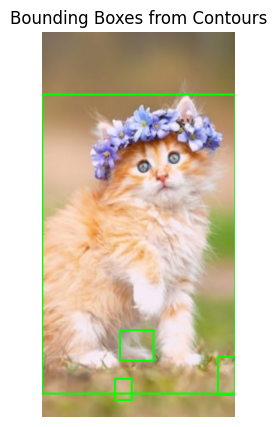

In [8]:
boxed_image = image_rgb.copy()

for cnt in valid_contours:
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(boxed_image, (x, y), (x+w, y+h), (0, 255, 0), 2)

plt.imshow(boxed_image)
plt.title("Bounding Boxes from Contours")
plt.axis("off")
plt.show()

## 7. Convolution: applying filters

A convolution filter scans the image and produces a new response image.  
Different filters highlight different patterns.


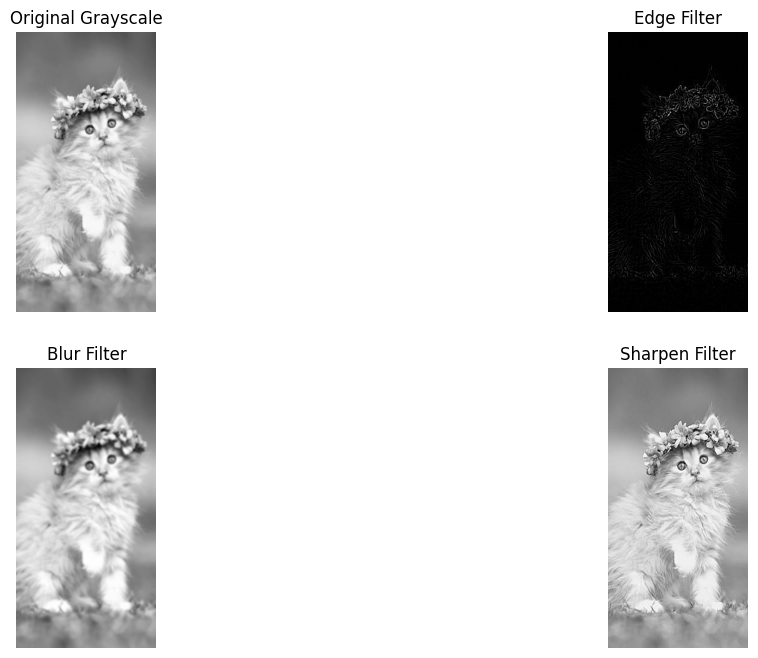

In [9]:
# Three simple filters
edge_kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

blur_kernel = np.ones((5, 5), np.float32) / 25

sharpen_kernel = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

edge_response = cv2.filter2D(gray, -1, edge_kernel)
blur_response = cv2.filter2D(gray, -1, blur_kernel)
sharpen_response = cv2.filter2D(gray, -1, sharpen_kernel)

plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(edge_response, cmap="gray")
plt.title("Edge Filter")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(blur_response, cmap="gray")
plt.title("Blur Filter")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(sharpen_response, cmap="gray")
plt.title("Sharpen Filter")
plt.axis("off")

plt.show()

## 8. One image, three views

The same image can be analysed in different ways:

- **HOG** summarises edge directions.
- **Contours** trace object boundaries.
- **Convolution** applies filters to detect patterns.


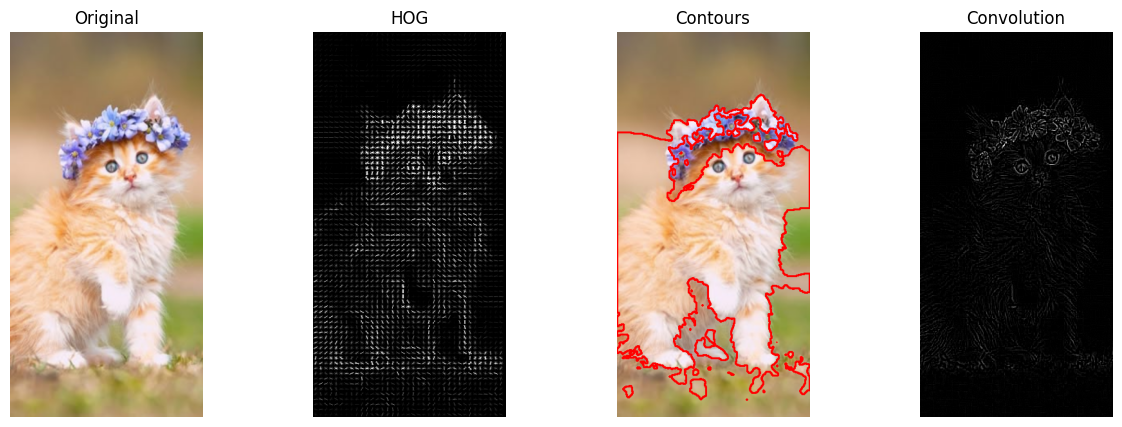

In [10]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(image_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(hog_image_rescaled, cmap="gray")
plt.title("HOG")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(contour_image)
plt.title("Contours")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(edge_response, cmap="gray")
plt.title("Convolution")
plt.axis("off")

plt.show()

## 9. Final connection

Traditional computer vision often depends on manually designed features such as HOG and contours.

CNNs also use convolution, but the filters are learned from data instead of being manually fixed.
